# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [ ]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "VISp"        # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut
To: /content/datos.npz
100%|██████████| 22.6M/22.6M [00:00<00:00, 51.3MB/s]


Área: VISp  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [ ]:
# 1. Número total de neuronas
n_neuronas = len(d["u_id"])

# 2. Número de ratones distintos
ratones = np.unique(d["u_raton"])
n_ratones = len(ratones)

# 3. Número de ensayos de cada clase de estímulo
clases, conteos = np.unique(d["e_clase"], return_counts=True)

# 4. Número total de potenciales de acción (PAs)
n_PAs = len(d["s_t"])


# -------- Mostrar resultados --------

print("Número total de neuronas:", n_neuronas)
print("Número de ratones:", n_ratones)
print("Ratones:", ratones)

print("\nEnsayos por clase de estímulo:")
for clase, cantidad in zip(clases, conteos):
    print(f"{clase}: {cantidad}")

print("\nNúmero total de PAs:", n_PAs)

Número total de neuronas: 382
Número de ratones: 5
Ratones: [715093703 750749662 760345702 762120172 798911424]

Ensayos por clase de estímulo:
drifting_gratings: 2000
flashes: 750
natural_movie_one: 40
natural_scenes: 2000
spontaneous: 750
static_gratings: 1250

Número total de PAs: 5666867


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [ ]:

# Índices de ensayos de rejillas en movimiento
idx_drifting = np.where(d["e_clase"] == "drifting_gratings")[0]

# Índices de ensayos espontáneos
idx_spontaneous = np.where(d["e_clase"] == "spontaneous")[0]

# Mostrar cuántos ensayos hay de cada tipo
print("Ensayos de drifting gratings:", len(idx_drifting))
print("Ensayos espontáneos:", len(idx_spontaneous))

Ensayos de drifting gratings: 2000
Ensayos espontáneos: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [ ]:
# PASO 3 · Tasa de disparo de cada neurona en cada ensayo

n_neuronas = len(d["u_id"])

# --------------------------------------------------
# 1. Crear matrices de conteos
# --------------------------------------------------

# Filas = neuronas
# Columnas = ensayos

conteos_drifting = np.zeros(
    (n_neuronas, len(idx_drifting)),
    dtype=int
)

conteos_spontaneous = np.zeros(
    (n_neuronas, len(idx_spontaneous)),
    dtype=int
)


# --------------------------------------------------
# 2. Crear mapas: índice global del ensayo -> columna
# --------------------------------------------------

map_drifting = np.full(len(d["e_clase"]), -1, dtype=int)
map_drifting[idx_drifting] = np.arange(len(idx_drifting))

map_spontaneous = np.full(len(d["e_clase"]), -1, dtype=int)
map_spontaneous[idx_spontaneous] = np.arange(len(idx_spontaneous))


# --------------------------------------------------
# 3. Quedarnos con PAs entre 0 y 2 segundos
# --------------------------------------------------

ventana = (d["s_t"] >= 0) & (d["s_t"] < 2)


# --------------------------------------------------
# 4. Contar PAs en ensayos de drifting gratings
# --------------------------------------------------

mask_drifting = ventana & (map_drifting[d["s_ensayo"]] >= 0)

unidades_d = d["s_unidad"][mask_drifting]
columnas_d = map_drifting[d["s_ensayo"][mask_drifting]]

np.add.at(
    conteos_drifting,
    (unidades_d, columnas_d),
    1
)


# --------------------------------------------------
# 5. Contar PAs en ensayos espontáneos
# --------------------------------------------------

mask_spontaneous = ventana & (map_spontaneous[d["s_ensayo"]] >= 0)

unidades_s = d["s_unidad"][mask_spontaneous]
columnas_s = map_spontaneous[d["s_ensayo"][mask_spontaneous]]

np.add.at(
    conteos_spontaneous,
    (unidades_s, columnas_s),
    1
)


# --------------------------------------------------
# 6. Convertir conteos a tasa de disparo (Hz)
# --------------------------------------------------

# La ventana dura 2 segundos
tasa_drifting = conteos_drifting / 2
tasa_spontaneous = conteos_spontaneous / 2


# --------------------------------------------------
# 7. Eliminar combinaciones neurona-ensayo
#    que pertenecen a ratones diferentes
# --------------------------------------------------

mismo_raton_d = (
    d["u_raton"][:, None]
    == d["e_raton"][idx_drifting][None, :]
)

mismo_raton_s = (
    d["u_raton"][:, None]
    == d["e_raton"][idx_spontaneous][None, :]
)

# NaN = ese ensayo pertenece a otro ratón
tasa_drifting = np.where(
    mismo_raton_d,
    tasa_drifting,
    np.nan
)

tasa_spontaneous = np.where(
    mismo_raton_s,
    tasa_spontaneous,
    np.nan
)


# --------------------------------------------------
# 8. Comprobaciones
# --------------------------------------------------

print("Forma matriz drifting:", tasa_drifting.shape)
print("Forma matriz spontaneous:", tasa_spontaneous.shape)

print(
    "Ensayos drifting por neurona:",
    np.unique(np.sum(~np.isnan(tasa_drifting), axis=1))
)

print(
    "Ensayos spontaneous por neurona:",
    np.unique(np.sum(~np.isnan(tasa_spontaneous), axis=1))
)

print(
    "Tasa evocada mediana:",
    np.nanmedian(tasa_drifting),
    "Hz"
)

print(
    "Tasa basal mediana:",
    np.nanmedian(tasa_spontaneous),
    "Hz"
)

import pandas as pd

# ============================================
# TABLA 1 · Tasa evocada
# ============================================

tabla_evocada = pd.DataFrame(
    tasa_drifting,
    index=[f"Neurona {i}" for i in range(n_neuronas)],
    columns=[f"Ensayo {i}" for i in idx_drifting]
)

print("TABLA 1 · TASA EVOCADA")
display(tabla_evocada)


# ============================================
# TABLA 2 · Tasa basal
# ============================================

tabla_basal = pd.DataFrame(
    tasa_spontaneous,
    index=[f"Neurona {i}" for i in range(n_neuronas)],
    columns=[f"Ensayo {i}" for i in idx_spontaneous]
)

print("TABLA 2 · TASA BASAL")
display(tabla_basal)


# ============================================
# TABLA 3 · Resumen por neurona
# ============================================

tabla_resumen = pd.DataFrame({
    "Neurona": np.arange(n_neuronas),
    "Ratón": d["u_raton"],
    "Tasa evocada promedio (Hz)": np.nanmean(tasa_drifting, axis=1),
    "Tasa basal promedio (Hz)": np.nanmean(tasa_spontaneous, axis=1)
})

print("TABLA 3 · RESUMEN")
display(tabla_resumen)

Forma matriz drifting: (382, 2000)
Forma matriz spontaneous: (382, 750)
Ensayos drifting por neurona: [400]
Ensayos spontaneous por neurona: [150]
Tasa evocada mediana: 1.5 Hz
Tasa basal mediana: 1.0 Hz
TABLA 1 · TASA EVOCADA


,Ensayo 0,Ensayo 1,Ensayo 2,Ensayo 3,Ensayo 4,Ensayo 5,Ensayo 6,Ensayo 7,Ensayo 8,Ensayo 9,...,Ensayo 5822,Ensayo 5823,Ensayo 5824,Ensayo 5825,Ensayo 5826,Ensayo 5827,Ensayo 5828,Ensayo 5829,Ensayo 5830,Ensayo 5831
Neurona 0,0.5,0.5,10.0,1.0,7.0,0.0,0.0,1.5,4.0,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 1,0.0,0.0,26.0,0.0,28.5,15.5,0.0,0.0,17.0,15.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 2,4.0,3.0,0.5,1.5,0.5,0.0,2.0,0.5,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 3,0.0,0.0,18.0,0.0,17.0,0.5,0.0,0.0,17.0,15.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 4,5.0,9.0,3.5,12.0,4.0,10.0,4.0,7.5,1.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Neurona 377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.5,0.5,0.0,0.5,4.0,0.0,4.0,1.5,3.0
Neurona 378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.5,0.0,0.5,1.0,6.0,0.5,2.0,0.0,4.0
Neurona 379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,5.0,1.5,1.5,3.5,1.0,6.5,4.0
Neurona 380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.5,4.0,0.5,0.0,1.5,4.0,0.0,4.0,2.5,7.5


TABLA 2 · TASA BASAL


,Ensayo 958,Ensayo 959,Ensayo 960,Ensayo 961,Ensayo 962,Ensayo 963,Ensayo 964,Ensayo 965,Ensayo 966,Ensayo 967,...,Ensayo 6530,Ensayo 6531,Ensayo 6532,Ensayo 6533,Ensayo 6534,Ensayo 6535,Ensayo 6536,Ensayo 6537,Ensayo 6538,Ensayo 6539
Neurona 0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 1,4.5,4.5,6.5,3.5,8.5,2.5,4.0,2.0,1.5,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 3,1.5,0.5,1.0,1.0,0.0,0.5,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neurona 4,3.5,5.0,6.5,3.0,6.5,2.5,8.0,1.5,7.5,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Neurona 377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.5,0.0,0.0,0.5,1.5,0.5,1.0,0.0,2.0,1.0
Neurona 378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.5,0.5,0.0,0.0,2.5,0.0,1.5,3.0,4.5,2.0
Neurona 379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.5,1.0,0.0,1.0,0.0,0.0,0.5,0.5,1.5
Neurona 380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,0.5,0.5,0.0,3.5,0.0,2.5,3.5,4.5,1.5


TABLA 3 · RESUMEN


,Neurona,Ratón,Tasa evocada promedio (Hz),Tasa basal promedio (Hz)
0,0,798911424,1.28375,1.186667
1,1,798911424,5.58625,1.596667
2,2,798911424,0.93000,3.846667
3,3,798911424,4.73125,0.193333
4,4,798911424,1.70250,1.003333
...,...,...,...,...
377,377,750749662,2.12375,1.083333
378,378,750749662,1.96750,1.373333
379,379,750749662,2.24250,0.870000
380,380,750749662,3.71625,2.610000


### Descripción de las tablas del paso 3

**Tabla 1. Tasa evocada:**  
Esta tabla contiene la tasa de disparo de cada neurona durante los ensayos de rejillas en movimiento (`drifting_gratings`). Cada fila corresponde a una neurona y cada columna a un ensayo. Los valores están expresados en Hz y representan cuántos potenciales de acción por segundo presentó cada neurona durante la ventana analizada del estímulo.

**Tabla 2. Tasa basal:**  
Esta tabla contiene la tasa de disparo de cada neurona durante los ensayos espontáneos (`spontaneous`), es decir, cuando no se presenta un estímulo visual. Al igual que en la tabla anterior, cada fila corresponde a una neurona y cada columna a un ensayo. Estos valores se utilizan como referencia de la actividad basal de cada neurona.

**Tabla 3. Resumen por neurona:**  
Esta tabla resume la información principal de cada neurona. Incluye su índice, el ratón al que pertenece, su tasa de disparo promedio durante las rejillas en movimiento y su tasa de disparo promedio durante la actividad espontánea. Esta tabla facilita la comparación entre la actividad evocada por el estímulo y la actividad basal.


--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [ ]:
# PASO 4 · Fracción de neuronas respondedoras
# Usando la combinación preferida de drifting gratings

# --------------------------------------------------
# 1. Media y desviación estándar basal de cada neurona
# --------------------------------------------------

media_basal = np.nanmean(tasa_spontaneous, axis=1)
std_basal = np.nanstd(tasa_spontaneous, axis=1, ddof=0)


# --------------------------------------------------
# 2. Características de los ensayos de drifting
# --------------------------------------------------

orientacion = d["e_orientacion"][idx_drifting]
frec_temporal = d["e_frec_temporal"][idx_drifting]
frec_espacial = d["e_frec_espacial"][idx_drifting]


# --------------------------------------------------
# 3. Quitar los barridos en blanco
# --------------------------------------------------

validos = (
    ~np.isnan(orientacion) &
    ~np.isnan(frec_temporal) &
    ~np.isnan(frec_espacial)
)


# --------------------------------------------------
# 4. Encontrar todas las combinaciones de estímulo
# --------------------------------------------------

combinaciones = np.unique(
    np.column_stack([
        orientacion[validos],
        frec_temporal[validos],
        frec_espacial[validos]
    ]),
    axis=0
)

print("Número de combinaciones:", len(combinaciones))


# --------------------------------------------------
# 5. Calcular un Z-score para cada combinación
#    en cada neurona
# --------------------------------------------------

z_por_combinacion = np.full(
    (n_neuronas, len(combinaciones)),
    np.nan
)

respuesta_por_combinacion = np.full(
    (n_neuronas, len(combinaciones)),
    np.nan
)


for j, (ori, ft, fe) in enumerate(combinaciones):

    # Ensayos que corresponden exactamente
    # a esta combinación
    mask_condicion = (
        (orientacion == ori) &
        (frec_temporal == ft) &
        (frec_espacial == fe)
    )

    # Tasa evocada promedio de cada neurona
    respuesta_media = np.nanmean(
        tasa_drifting[:, mask_condicion],
        axis=1
    )

    respuesta_por_combinacion[:, j] = respuesta_media

    # Z-score de esta condición
    z_por_combinacion[:, j] = (
        respuesta_media - media_basal
    ) / std_basal


# --------------------------------------------------
# 6. Escoger el Z-score MÁS ALTO de cada neurona
# --------------------------------------------------

z_score = np.nanmax(
    z_por_combinacion,
    axis=1
)

indice_preferido = np.nanargmax(
    z_por_combinacion,
    axis=1
)


# --------------------------------------------------
# 7. Guardar cuál fue la condición preferida
# --------------------------------------------------

orientacion_preferida = combinaciones[indice_preferido, 0]
frec_temporal_preferida = combinaciones[indice_preferido, 1]
frec_espacial_preferida = combinaciones[indice_preferido, 2]


# --------------------------------------------------
# 8. Determinar cuáles neuronas responden
# --------------------------------------------------

umbral = 2.5

respondedoras = z_score >= umbral

n_respondedoras = np.sum(respondedoras)

fraccion_respondedoras = (
    n_respondedoras / n_neuronas
)

porcentaje_respondedoras = (
    fraccion_respondedoras * 100
)


# --------------------------------------------------
# 9. Mostrar resultados
# --------------------------------------------------

print("\nNeuronas totales:", n_neuronas)
print("Neuronas respondedoras:", n_respondedoras)

print(
    f"Fracción respondedora: "
    f"{fraccion_respondedoras:.3f}"
)

print(
    f"Porcentaje de neuronas respondedoras: "
    f"{porcentaje_respondedoras:.2f}%"
)

print(
    f"Mediana del Z-score máximo: "
    f"{np.nanmedian(z_score):.2f}"
)

Número de combinaciones: 40

Neuronas totales: 382
Neuronas respondedoras: 187
Fracción respondedora: 0.490
Porcentaje de neuronas respondedoras: 48.95%
Mediana del Z-score máximo: 2.39


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [ ]:
# PASO 5 · La misma cuenta, ratón por ratón

ratones = np.unique(d["u_raton"])

fracciones_por_raton = []
n_neuronas_por_raton = []

for raton in ratones:

    # Neuronas que pertenecen a este ratón
    mask_raton = d["u_raton"] == raton

    # Número de neuronas de este ratón
    n_neuronas_raton = np.sum(mask_raton)

    # Número de respondedoras de este ratón
    n_respondedoras_raton = np.sum(respondedoras[mask_raton])

    # Fracción respondedora
    fraccion = n_respondedoras_raton / n_neuronas_raton

    # Guardar para usar después en la gráfica
    n_neuronas_por_raton.append(n_neuronas_raton)
    fracciones_por_raton.append(fraccion)

    # Mostrar resultados
    print(
        f"Ratón {raton}: "
        f"{n_respondedoras_raton}/{n_neuronas_raton} respondedoras "
        f"= {fraccion:.3f} ({100*fraccion:.2f}%)"
    )

Ratón 715093703: 33/62 respondedoras = 0.532 (53.23%)
Ratón 750749662: 25/60 respondedoras = 0.417 (41.67%)
Ratón 760345702: 43/77 respondedoras = 0.558 (55.84%)
Ratón 762120172: 44/88 respondedoras = 0.500 (50.00%)
Ratón 798911424: 42/95 respondedoras = 0.442 (44.21%)


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

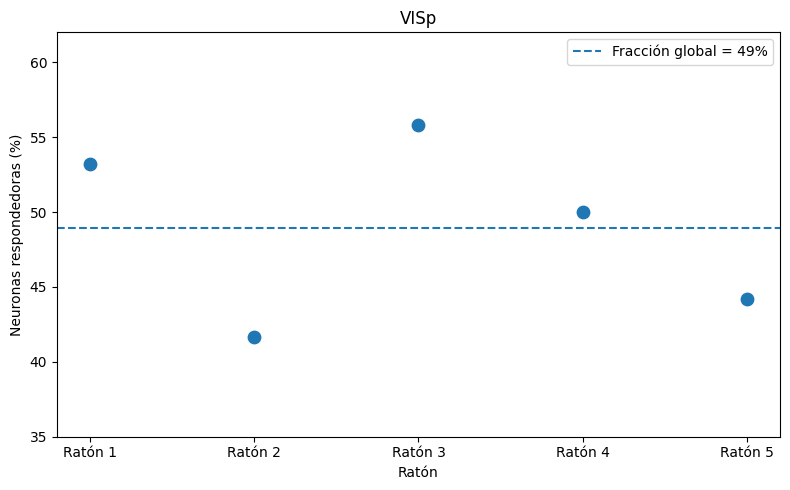

In [ ]:


# PASO 6 · Gráfica mejorada

import matplotlib.pyplot as plt
import numpy as np

fracciones_por_raton = np.array(fracciones_por_raton)

x = np.arange(len(fracciones_por_raton))
labels = [f"Ratón {i+1}" for i in range(len(fracciones_por_raton))]

plt.figure(figsize=(8,5))

# Puntos de cada ratón
plt.scatter(
    x,
    fracciones_por_raton * 100,
    s=80
)

# Fracción global
plt.axhline(
    fraccion_respondedoras * 100,
    linestyle="--",
    label=f"Fracción global = {100*fraccion_respondedoras:.0f}%"
)

# Ejes
plt.xticks(x, labels)
plt.xlabel("Ratón")
plt.ylabel("Neuronas respondedoras (%)")

# Título
plt.title("VISp")

# Acercar el eje Y a los datos
plt.ylim(35, 62)

plt.legend()
plt.tight_layout()
plt.show()

# **Figura 1C**


Neurona ejemplo: 343
Z-score: 194.6042393031332


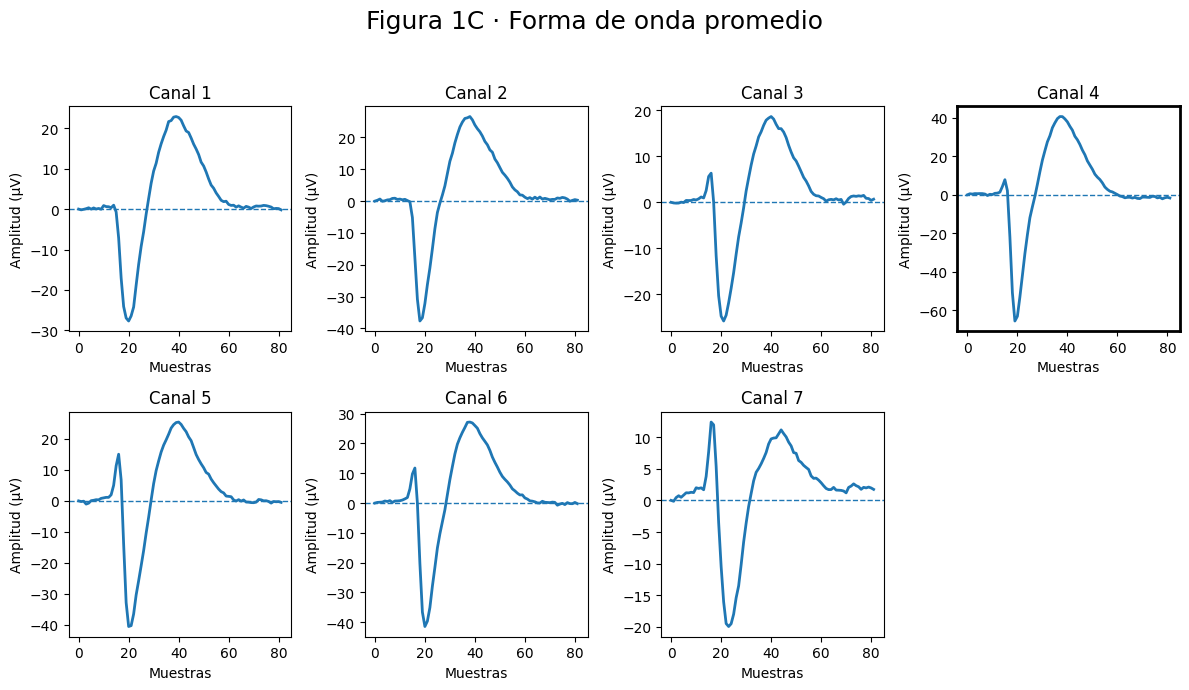

In [ ]:
# FIGURA 1C · Forma de onda promedio de una neurona ejemplo


# -----------------------------------------
# 1. Escoger una neurona ejemplo respondedora
#    (por ejemplo, la respondedora con mayor Z-score)
# -----------------------------------------

indices_resp = np.where(respondedoras)[0]

if len(indices_resp) == 0:
    raise ValueError("No hay neuronas respondedoras con el umbral actual.")

idx_ejemplo = indices_resp[np.nanargmax(z_score[indices_resp])]

print("Neurona ejemplo:", idx_ejemplo)
print("Z-score:", z_score[idx_ejemplo])

# -----------------------------------------
# 2. Extraer la forma de onda promedio
# -----------------------------------------

onda = d["u_onda"][idx_ejemplo]

# Asegurar que quede con forma (7, n_tiempo)
if onda.shape[0] != 7 and onda.shape[1] == 7:
    onda = onda.T

if onda.shape[0] != 7:
    raise ValueError(f"La onda no tiene 7 canales en la primera dimensión. Shape actual: {onda.shape}")

n_canales, n_t = onda.shape

# Eje x: muestras
x = np.arange(n_t)

# Canal con mayor amplitud absoluta
canal_principal = np.argmax(np.max(np.abs(onda), axis=1))

# -----------------------------------------
# 3. Graficar
# -----------------------------------------

fig = plt.figure(figsize=(12, 7))

for i in range(7):
    ax = plt.subplot(2, 4, i + 1)

    ax.plot(x, onda[i], linewidth=2)
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"Canal {i+1}", fontsize=12)
    ax.set_xlabel("Muestras")
    ax.set_ylabel("Amplitud (µV)")

    # Resaltar el canal principal
    if i == canal_principal:
        for spine in ax.spines.values():
            spine.set_linewidth(2)

plt.suptitle("Figura 1C · Forma de onda promedio", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

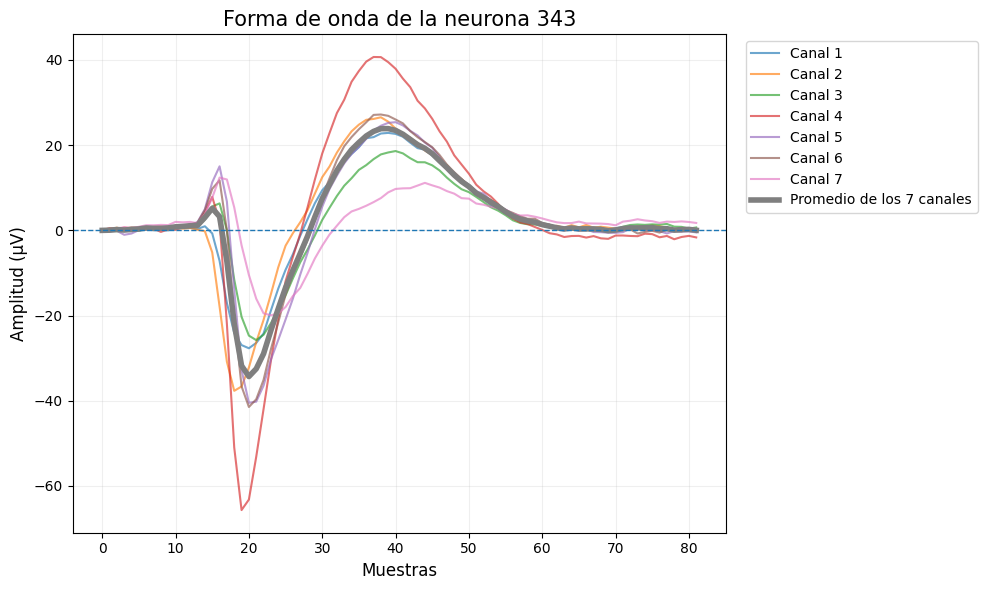

In [ ]:
# ==========================================================
# FIGURA EXTRA · FORMAS DE ONDA SUPERPUESTAS
# Neurona ejemplo
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# Tomar la forma de onda de la neurona ejemplo
onda = np.array(d["u_onda"][idx_ejemplo])

# Asegurarnos de que quede:
# 7 canales x número de muestras
if onda.shape[0] != 7 and onda.shape[1] == 7:
    onda = onda.T

# Eje X
muestras = np.arange(onda.shape[1])

# Promedio punto a punto de los 7 canales
promedio_canales = np.mean(onda, axis=0)


# ==========================================================
# GRÁFICA
# ==========================================================

plt.figure(figsize=(10, 6))

# Graficar los 7 canales superpuestos
for canal in range(7):

    plt.plot(
        muestras,
        onda[canal],
        linewidth=1.5,
        alpha=0.65,
        label=f"Canal {canal + 1}"
    )


# Promedio de los 7 canales
plt.plot(
    muestras,
    promedio_canales,
    linewidth=4,
    label="Promedio de los 7 canales"
)


# Línea de referencia en 0 µV
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# ==========================================================
# EJES Y ETIQUETAS
# ==========================================================

plt.xlabel(
    "Muestras",
    fontsize=12
)

plt.ylabel(
    "Amplitud (µV)",
    fontsize=12
)

plt.title(
    f"Forma de onda de la neurona {idx_ejemplo}",
    fontsize=15
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

# **FIgura 1D**


Neurona ejemplo: 343
Orientación preferida: 180.0
Frecuencia temporal preferida: 8.0 Hz
Frecuencia espacial: 0.04 cpd
Número de ensayos de la condición preferida: 10


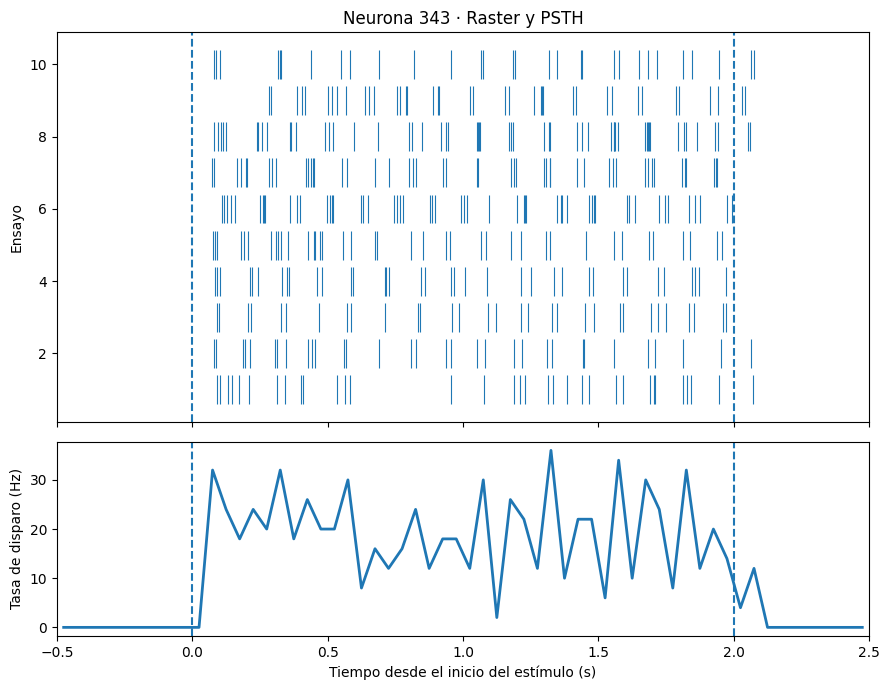

In [ ]:
# FIGURA 1D · Raster y PSTH de la neurona ejemplo



# --------------------------------------------------
# 1. Usar la MISMA neurona de la Figura 1C
# --------------------------------------------------

print("Neurona ejemplo:", idx_ejemplo)

# Condición preferida de esa neurona
ori_pref = orientacion_preferida[idx_ejemplo]
ft_pref  = frec_temporal_preferida[idx_ejemplo]
fe_pref  = frec_espacial_preferida[idx_ejemplo]

print("Orientación preferida:", ori_pref)
print("Frecuencia temporal preferida:", ft_pref, "Hz")
print("Frecuencia espacial:", fe_pref, "cpd")


# --------------------------------------------------
# 2. Encontrar los ensayos de su condición preferida
# --------------------------------------------------

raton_ejemplo = d["u_raton"][idx_ejemplo]

mask_ensayos = (
    (d["e_clase"] == "drifting_gratings") &
    (d["e_raton"] == raton_ejemplo) &
    (d["e_orientacion"] == ori_pref) &
    (d["e_frec_temporal"] == ft_pref) &
    (d["e_frec_espacial"] == fe_pref)
)

ensayos_pref = np.where(mask_ensayos)[0]

print("Número de ensayos de la condición preferida:",
      len(ensayos_pref))


# --------------------------------------------------
# 3. Extraer las espigas ensayo por ensayo
# --------------------------------------------------

spikes_por_ensayo = []

for ensayo in ensayos_pref:

    mask_spikes = (
        (d["s_unidad"] == idx_ejemplo) &
        (d["s_ensayo"] == ensayo)
    )

    tiempos = d["s_t"][mask_spikes]

    spikes_por_ensayo.append(tiempos)


# --------------------------------------------------
# 4. Ventana temporal
# --------------------------------------------------

# 0 s = inicio del estímulo
# El drifting dura 2 s

t_min = -0.5
t_max = 2.5

# Bin de 50 ms para el PSTH
bin_width = 0.05

bins = np.arange(
    t_min,
    t_max + bin_width,
    bin_width
)

centros = (bins[:-1] + bins[1:]) / 2


# --------------------------------------------------
# 5. Calcular PSTH por ensayo
# --------------------------------------------------

tasas_por_ensayo = []

for tiempos in spikes_por_ensayo:

    conteos, _ = np.histogram(
        tiempos,
        bins=bins
    )

    # Convertir a Hz
    tasa = conteos / bin_width

    tasas_por_ensayo.append(tasa)

tasas_por_ensayo = np.array(tasas_por_ensayo)

# Promedio entre ensayos
psth = np.mean(tasas_por_ensayo, axis=0)


# --------------------------------------------------
# 6. Graficar Raster + PSTH
# --------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# =========================
# Raster
# =========================

for i, tiempos in enumerate(spikes_por_ensayo):

    # Solo mostrar espigas dentro de la ventana
    tiempos_plot = tiempos[
        (tiempos >= t_min) &
        (tiempos <= t_max)
    ]

    ax1.vlines(
        tiempos_plot,
        i + 0.6,
        i + 1.4,
        linewidth=0.8
    )

# Inicio y final del estímulo
ax1.axvline(0, linestyle="--")
ax1.axvline(2, linestyle="--")

ax1.set_ylabel("Ensayo")
ax1.set_title(
    f"Neurona {idx_ejemplo} · Raster y PSTH"
)


# =========================
# PSTH
# =========================

ax2.plot(
    centros,
    psth,
    linewidth=2
)

ax2.axvline(0, linestyle="--")
ax2.axvline(2, linestyle="--")

ax2.set_xlabel(
    "Tiempo desde el inicio del estímulo (s)"
)

ax2.set_ylabel(
    "Tasa de disparo (Hz)"
)

ax2.set_xlim(t_min, t_max)


plt.tight_layout()
plt.show()

# **Figura 2A**

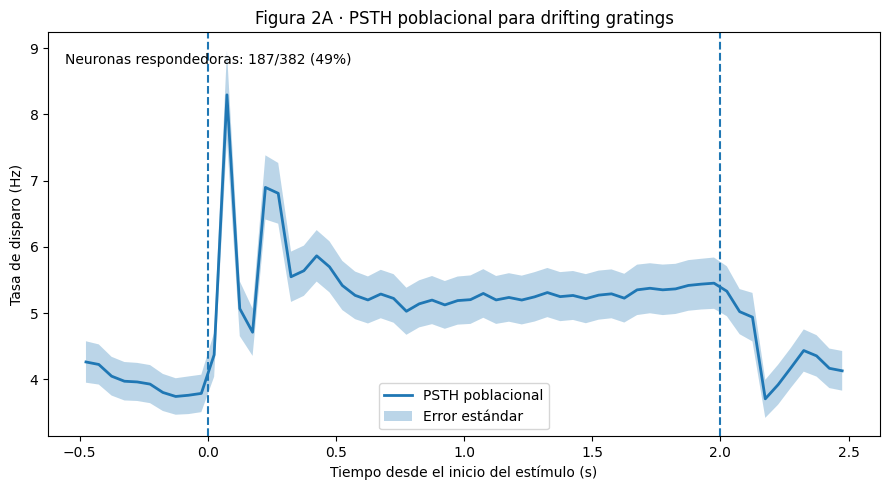

In [ ]:
# FIGURA 2A · PSTH poblacional para drifting gratings
# Versión rápida


# --------------------------------------------------
# 1. Parámetros
# --------------------------------------------------

t_min = -0.5
t_max = 2.5
bin_width = 0.05  # 50 ms

bins = np.arange(t_min, t_max + bin_width, bin_width)
centros = (bins[:-1] + bins[1:]) / 2

n_bins = len(bins) - 1


# --------------------------------------------------
# 2. Identificar qué ensayos son drifting gratings
# --------------------------------------------------

es_drifting = np.zeros(len(d["e_clase"]), dtype=bool)
es_drifting[idx_drifting] = True


# --------------------------------------------------
# 3. Seleccionar solamente PAs de drifting
#    dentro de nuestra ventana temporal
# --------------------------------------------------

mask = (
    es_drifting[d["s_ensayo"]] &
    (d["s_t"] >= t_min) &
    (d["s_t"] < t_max)
)

unidades = d["s_unidad"][mask]
tiempos = d["s_t"][mask]


# --------------------------------------------------
# 4. Convertir cada tiempo a un bin
# --------------------------------------------------

bin_idx = ((tiempos - t_min) / bin_width).astype(int)


# --------------------------------------------------
# 5. Contar PAs por neurona y por bin
# --------------------------------------------------

conteos = np.zeros(
    (n_neuronas, n_bins),
    dtype=int
)

np.add.at(
    conteos,
    (unidades, bin_idx),
    1
)


# --------------------------------------------------
# 6. Número de ensayos drifting para cada neurona
# --------------------------------------------------

n_ensayos_neurona = np.zeros(n_neuronas)

for i in range(n_neuronas):

    raton = d["u_raton"][i]

    n_ensayos_neurona[i] = np.sum(
        d["e_raton"][idx_drifting] == raton
    )


# --------------------------------------------------
# 7. PSTH de cada neurona
# --------------------------------------------------

psth_por_neurona = (
    conteos /
    n_ensayos_neurona[:, None] /
    bin_width
)


# --------------------------------------------------
# 8. Promedio poblacional + error estándar
# --------------------------------------------------

psth_media = np.mean(
    psth_por_neurona,
    axis=0
)

psth_sem = (
    np.std(
        psth_por_neurona,
        axis=0,
        ddof=1
    )
    / np.sqrt(n_neuronas)
)


# --------------------------------------------------
# 9. Gráfica
# --------------------------------------------------

plt.figure(figsize=(9,5))

plt.plot(
    centros,
    psth_media,
    linewidth=2,
    label="PSTH poblacional"
)

plt.fill_between(
    centros,
    psth_media - psth_sem,
    psth_media + psth_sem,
    alpha=0.3,
    label="Error estándar"
)

# Inicio y final del estímulo
plt.axvline(0, linestyle="--")
plt.axvline(2, linestyle="--")

plt.xlabel("Tiempo desde el inicio del estímulo (s)")
plt.ylabel("Tasa de disparo (Hz)")
plt.title("Figura 2A · PSTH poblacional para drifting gratings")

plt.text(
    0.02, 0.95,
    f"Neuronas respondedoras: "
    f"{n_respondedoras}/{n_neuronas} "
    f"({100*fraccion_respondedoras:.0f}%)",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.legend()
plt.tight_layout()
plt.show()





# Figura **2B**

Espigas organizadas correctamente


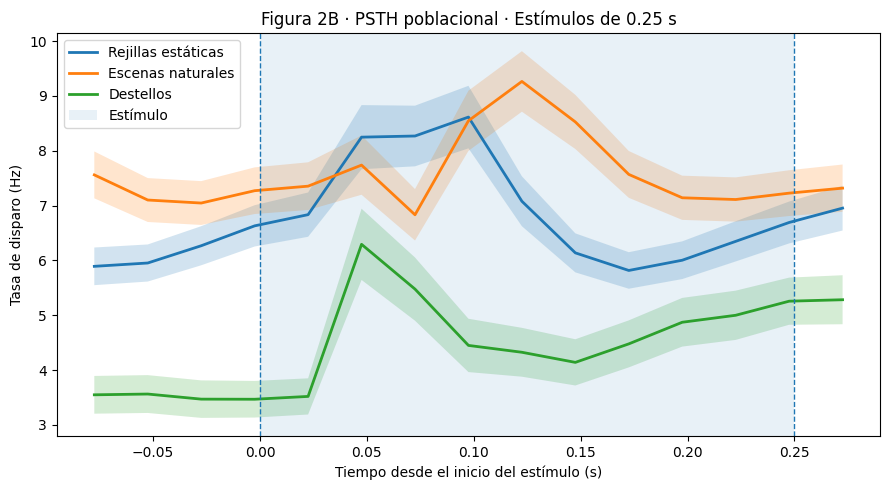

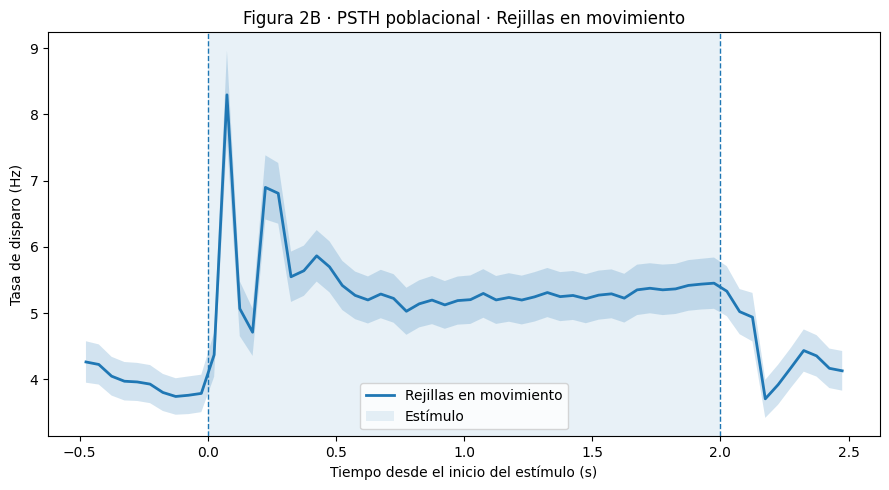

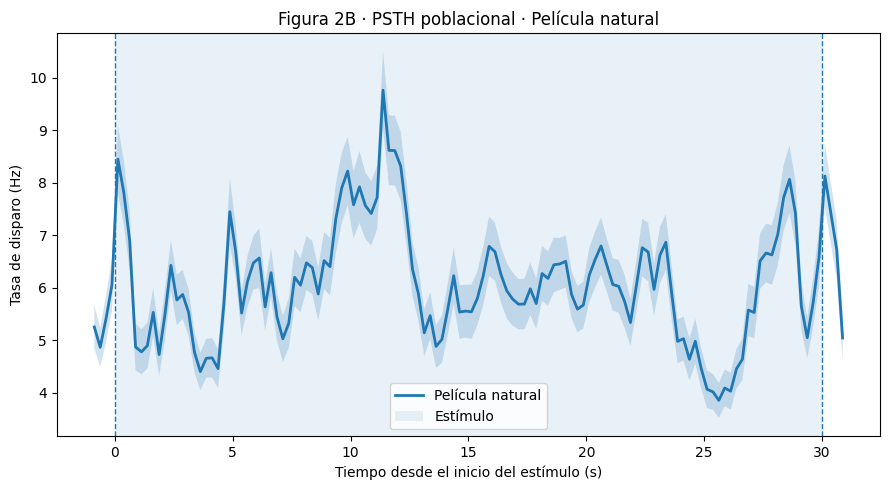

In [ ]:
# ============================================================
# FIGURA 2B · PSTH POBLACIONAL POR CLASE DE ESTÍMULO
# CON ACTIVIDAD BASAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# ============================================================
# 1. PREAGRUPAR ESPIGAS POR (NEURONA, ENSAYO)
# ============================================================

spikes_por_neurona_ensayo = defaultdict(list)

for u, e, t in zip(
    d["s_unidad"],
    d["s_ensayo"],
    d["s_t"]
):
    spikes_por_neurona_ensayo[(int(u), int(e))].append(t)

for key in spikes_por_neurona_ensayo:
    spikes_por_neurona_ensayo[key] = np.array(
        spikes_por_neurona_ensayo[key]
    )

print("Espigas organizadas correctamente")


# ============================================================
# 2. FUNCIÓN PARA CALCULAR PSTH POBLACIONAL
# ============================================================

def calcular_psth_poblacional_rapido(
    clase,
    t_min,
    t_max,
    bin_width
):

    idx_ensayos = np.where(
        d["e_clase"] == clase
    )[0]

    bins = np.arange(
        t_min,
        t_max + bin_width,
        bin_width
    )

    centros = (
        bins[:-1] + bins[1:]
    ) / 2

    n_bins = len(centros)

    psth_neuronas = np.full(
        (n_neuronas, n_bins),
        np.nan
    )

    for neurona in range(n_neuronas):

        raton = d["u_raton"][neurona]

        ensayos_neurona = idx_ensayos[
            d["e_raton"][idx_ensayos] == raton
        ]

        if len(ensayos_neurona) == 0:
            continue

        tasas_ensayos = []

        for ensayo in ensayos_neurona:

            tiempos = spikes_por_neurona_ensayo.get(
                (neurona, int(ensayo)),
                np.array([])
            )

            conteos, _ = np.histogram(
                tiempos,
                bins=bins
            )

            tasa = conteos / bin_width

            tasas_ensayos.append(tasa)

        psth_neuronas[neurona] = np.mean(
            tasas_ensayos,
            axis=0
        )

    media = np.nanmean(
        psth_neuronas,
        axis=0
    )

    n_validas = np.sum(
        ~np.isnan(psth_neuronas[:, 0])
    )

    sem = (
        np.nanstd(
            psth_neuronas,
            axis=0,
            ddof=1
        )
        /
        np.sqrt(n_validas)
    )

    return centros, media, sem, psth_neuronas


# ============================================================
# 3. ESTÍMULOS DE 0.25 s
# ============================================================

bin_width = 0.025

t_static, m_static, sem_static, _ = \
    calcular_psth_poblacional_rapido(
        "static_gratings",
        -0.09,
        0.28,
        bin_width
    )

t_scenes, m_scenes, sem_scenes, _ = \
    calcular_psth_poblacional_rapido(
        "natural_scenes",
        -0.09,
        0.28,
        bin_width
    )

t_flashes, m_flashes, sem_flashes, _ = \
    calcular_psth_poblacional_rapido(
        "flashes",
        -0.09,
        0.28,
        bin_width
    )


plt.figure(figsize=(9, 5))

plt.plot(
    t_static,
    m_static,
    linewidth=2,
    label="Rejillas estáticas"
)

plt.fill_between(
    t_static,
    m_static - sem_static,
    m_static + sem_static,
    alpha=0.2
)


plt.plot(
    t_scenes,
    m_scenes,
    linewidth=2,
    label="Escenas naturales"
)

plt.fill_between(
    t_scenes,
    m_scenes - sem_scenes,
    m_scenes + sem_scenes,
    alpha=0.2
)


plt.plot(
    t_flashes,
    m_flashes,
    linewidth=2,
    label="Destellos"
)

plt.fill_between(
    t_flashes,
    m_flashes - sem_flashes,
    m_flashes + sem_flashes,
    alpha=0.2
)


# zona del estímulo
plt.axvspan(
    0,
    0.25,
    alpha=0.10,
    label="Estímulo"
)

# inicio y final
plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0.25,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Tiempo desde el inicio del estímulo (s)"
)

plt.ylabel(
    "Tasa de disparo (Hz)"
)

plt.title(
    "Figura 2B · PSTH poblacional · Estímulos de 0.25 s"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 4. REJILLAS EN MOVIMIENTO · 2 s
# ============================================================

t_drift, m_drift, sem_drift, _ = \
    calcular_psth_poblacional_rapido(
        "drifting_gratings",
        -0.5,
        2.5,
        0.05
    )


plt.figure(figsize=(9, 5))

plt.plot(
    t_drift,
    m_drift,
    linewidth=2,
    label="Rejillas en movimiento"
)

plt.fill_between(
    t_drift,
    m_drift - sem_drift,
    m_drift + sem_drift,
    alpha=0.2
)

plt.axvspan(
    0,
    2,
    alpha=0.10,
    label="Estímulo"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    2,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Tiempo desde el inicio del estímulo (s)"
)

plt.ylabel(
    "Tasa de disparo (Hz)"
)

plt.title(
    "Figura 2B · PSTH poblacional · Rejillas en movimiento"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 5. PELÍCULA NATURAL · 30 s
# ============================================================

t_movie, m_movie, sem_movie, _ = \
    calcular_psth_poblacional_rapido(
        "natural_movie_one",
        -1,
        31,
        0.25
    )


plt.figure(figsize=(9, 5))

plt.plot(
    t_movie,
    m_movie,
    linewidth=2,
    label="Película natural"
)

plt.fill_between(
    t_movie,
    m_movie - sem_movie,
    m_movie + sem_movie,
    alpha=0.2
)

plt.axvspan(
    0,
    30,
    alpha=0.10,
    label="Estímulo"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    30,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Tiempo desde el inicio del estímulo (s)"
)

plt.ylabel(
    "Tasa de disparo (Hz)"
)

plt.title(
    "Figura 2B · PSTH poblacional · Película natural"
)

plt.legend()

plt.tight_layout()

plt.show()

# **Figura 2C**

z_heatmap creado: (382, 5)


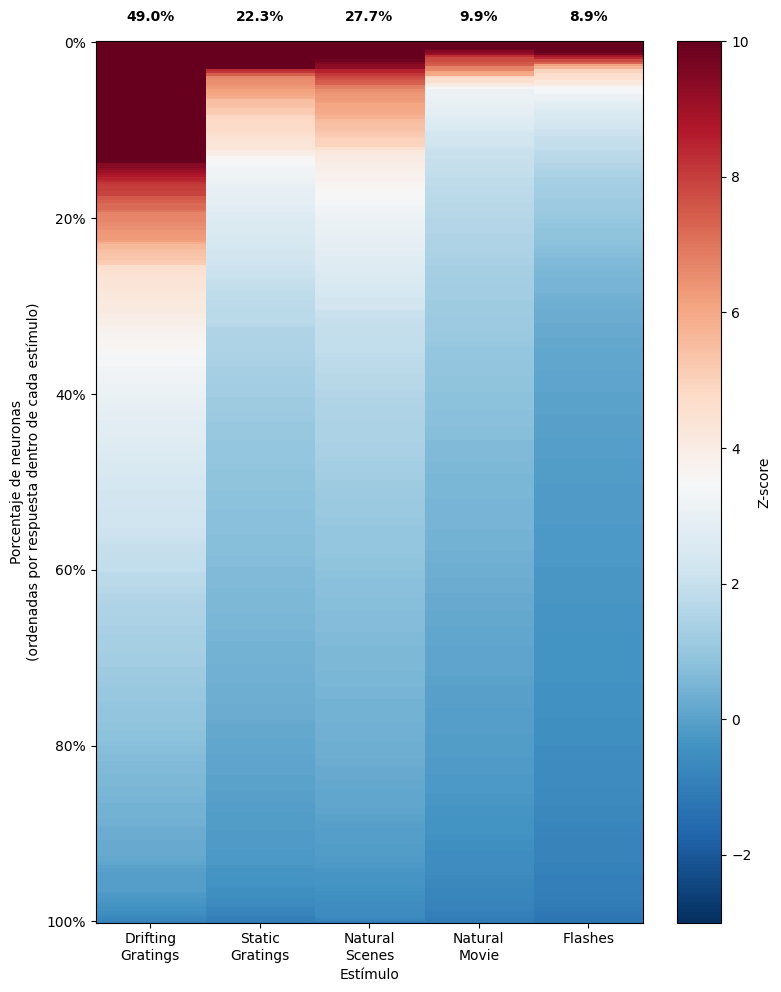

In [ ]:
# FIGURA 2C · Versión rápida

# ============================================================
# RECONSTRUIR z_heatmap
# ============================================================

clases_estimulo = [
    "drifting_gratings",
    "static_gratings",
    "natural_scenes",
    "natural_movie_one",
    "flashes"
]

# ------------------------------------------------------------
# 1. Tasas de disparo de todas las neuronas en todos los ensayos
# ------------------------------------------------------------

n_ensayos_total = len(d["e_clase"])

conteos = np.zeros(
    (n_neuronas, n_ensayos_total),
    dtype=np.int32
)

# Duración del ensayo al que pertenece cada espiga
duracion_spike = d["e_dur"][d["s_ensayo"]]

# Solo contar espigas durante el estímulo
mask = (
    (d["s_t"] >= 0) &
    (d["s_t"] < duracion_spike)
)

np.add.at(
    conteos,
    (
        d["s_unidad"][mask],
        d["s_ensayo"][mask]
    ),
    1
)

# Convertir a Hz
tasas_todos_ensayos = conteos / d["e_dur"][None, :]

# No mezclar neuronas con ensayos de otros ratones
mismo_raton = (
    d["u_raton"][:, None]
    == d["e_raton"][None, :]
)

tasas_todos_ensayos = np.where(
    mismo_raton,
    tasas_todos_ensayos,
    np.nan
)

# ------------------------------------------------------------
# 2. Crear matriz de Z-scores
# filas = neuronas
# columnas = estímulos
# ------------------------------------------------------------

z_heatmap = np.full(
    (n_neuronas, len(clases_estimulo)),
    np.nan
)

# Drifting: usamos el Z de la combinación preferida
z_heatmap[:, 0] = z_score

# Los demás estímulos
for j, clase in enumerate(clases_estimulo[1:], start=1):

    idx = np.where(d["e_clase"] == clase)[0]

    tasa_media = np.nanmean(
        tasas_todos_ensayos[:, idx],
        axis=1
    )

    z_heatmap[:, j] = (
        tasa_media - media_basal
    ) / std_basal

print("z_heatmap creado:", z_heatmap.shape)


# ============================================================
# FIGURA 2C · CADA COLUMNA ORDENADA POR SEPARADO
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Matriz original:
# filas = neuronas
# columnas = estímulos
Z = z_heatmap.copy()

nombres_est = [
    "Drifting\nGratings",
    "Static\nGratings",
    "Natural\nScenes",
    "Natural\nMovie",
    "Flashes"
]

# ------------------------------------------------------------
# 1. Ordenar cada columna de mayor a menor
# ------------------------------------------------------------

Z_ordenado_cols = np.zeros_like(Z)

for j in range(Z.shape[1]):
    Z_ordenado_cols[:, j] = np.sort(Z[:, j])[::-1]

# ------------------------------------------------------------
# 2. Porcentaje de neuronas respondedoras por estímulo
#    usando el mismo umbral de respuesta
# ------------------------------------------------------------

umbral = 2.5
porcentajes = 100 * np.mean(Z > umbral, axis=0)

# ------------------------------------------------------------
# 3. Graficar
# ------------------------------------------------------------

plt.figure(figsize=(8, 10))

im = plt.imshow(
    Z_ordenado_cols,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-3,
    vmax=10,
    interpolation="nearest"
)

plt.xticks(
    np.arange(len(nombres_est)),
    nombres_est
)

# Eje y como porcentaje de neuronas
n = Z.shape[0]
yticks_pos = np.linspace(0, n-1, 6)
yticks_lab = [f"{int(x)}%" for x in np.linspace(0, 100, 6)]

plt.yticks(yticks_pos, yticks_lab)
plt.ylabel("Porcentaje de neuronas\n(ordenadas por respuesta dentro de cada estímulo)")
plt.xlabel("Estímulo")

# Barra de color
cbar = plt.colorbar(im)
cbar.set_label("Z-score")

# ------------------------------------------------------------
# 4. Escribir arriba el % de neuronas respondedoras
# ------------------------------------------------------------

for j, p in enumerate(porcentajes):
    plt.text(
        j,
        -8,                      # un poquito arriba del mapa
        f"{p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## **Figura 2D**

Mediana Z drifting: 2.385532748150155
Mediana Z static: 0.8755720512719658
Neuronas válidas drifting: 382
Neuronas válidas static: 382


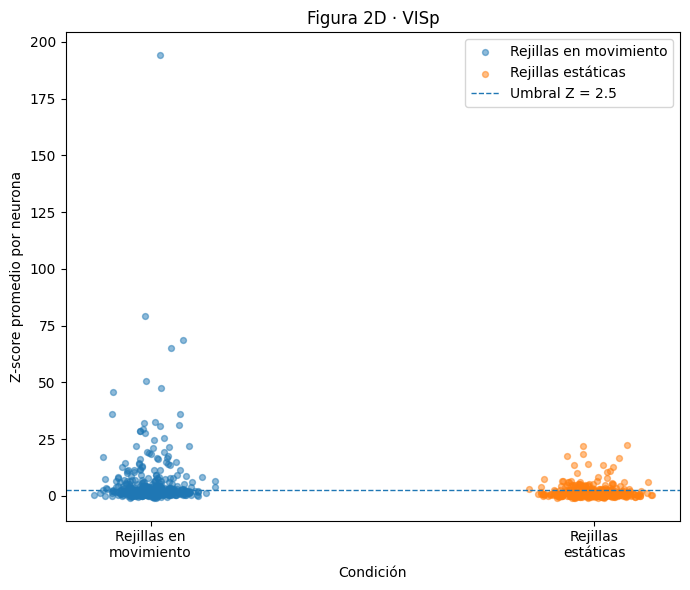

In [ ]:
# FIGURA 2D · Z-score por condición asignada
# VISp: drifting gratings vs static gratings

# --------------------------------------------------
# 1. Matrices para guardar el Z promedio por neurona
# --------------------------------------------------

z_drifting = np.full(n_neuronas, np.nan)
z_static = np.full(n_neuronas, np.nan)


# --------------------------------------------------
# 2. DRIFTING GRATINGS
#    Usar la combinación preferida de cada neurona
# --------------------------------------------------

for i in range(n_neuronas):

    raton_i = d["u_raton"][i]

    # Parámetros preferidos de esta neurona
    ori_pref = orientacion_preferida[i]
    ft_pref = frec_temporal_preferida[i]
    fe_pref = frec_espacial_preferida[i]

    # Ensayos correspondientes a SU condición preferida
    mask = (
        (d["e_clase"] == "drifting_gratings") &
        (d["e_raton"] == raton_i) &
        (d["e_orientacion"] == ori_pref) &
        (d["e_frec_temporal"] == ft_pref) &
        (d["e_frec_espacial"] == fe_pref)
    )

    ensayos = np.where(mask)[0]

    # Tasas de esa neurona en esos ensayos
    tasas = tasas_todos_ensayos[i, ensayos]

    # Z de cada ensayo respecto al basal propio
    z_ensayos = (
        tasas - media_basal[i]
    ) / std_basal[i]

    # Promedio de Z entre ensayos
    z_drifting[i] = np.nanmean(z_ensayos)


# --------------------------------------------------
# 3. STATIC GRATINGS
#    Promedio de todos los ensayos static del ratón
# --------------------------------------------------

for i in range(n_neuronas):

    raton_i = d["u_raton"][i]

    mask = (
        (d["e_clase"] == "static_gratings") &
        (d["e_raton"] == raton_i)
    )

    ensayos = np.where(mask)[0]

    tasas = tasas_todos_ensayos[i, ensayos]

    # Z de cada ensayo
    z_ensayos = (
        tasas - media_basal[i]
    ) / std_basal[i]

    # Promedio de Z entre ensayos
    z_static[i] = np.nanmean(z_ensayos)


# --------------------------------------------------
# 4. Comprobaciones
# --------------------------------------------------

print("Mediana Z drifting:", np.nanmedian(z_drifting))
print("Mediana Z static:", np.nanmedian(z_static))

print("Neuronas válidas drifting:", np.sum(~np.isnan(z_drifting)))
print("Neuronas válidas static:", np.sum(~np.isnan(z_static)))


# --------------------------------------------------
# 5. Enjambre
# --------------------------------------------------

rng = np.random.default_rng(42)

jitter_d = rng.normal(0, 0.05, n_neuronas)
jitter_s = rng.normal(0, 0.05, n_neuronas)

plt.figure(figsize=(7,6))

plt.scatter(
    1 + jitter_d,
    z_drifting,
    alpha=0.5,
    s=18,
    label="Rejillas en movimiento"
)

plt.scatter(
    2 + jitter_s,
    z_static,
    alpha=0.5,
    s=18,
    label="Rejillas estáticas"
)

# Umbral de respuesta
plt.axhline(
    2.5,
    linestyle="--",
    linewidth=1,
    label="Umbral Z = 2.5"
)

plt.xticks(
    [1, 2],
    ["Rejillas en\nmovimiento", "Rejillas\nestáticas"]
)

plt.ylabel("Z-score promedio por neurona")
plt.xlabel("Condición")
plt.title("Figura 2D · VISp")

plt.legend()
plt.tight_layout()
plt.show()

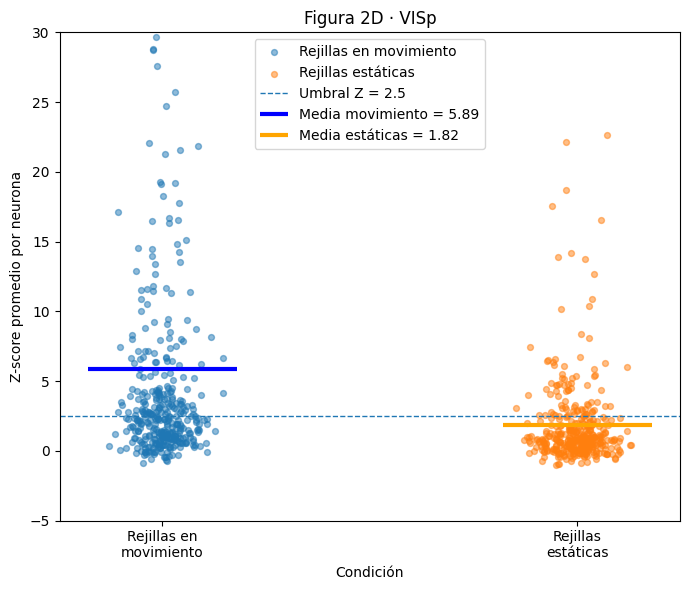

Media Z drifting: 5.892313162320804
Media Z static: 1.8167147203875762
Drifting con Z > 30: 13
Static con Z > 30: 0


In [39]:
# FIGURA 2D · Versión visualmente más clara

# FIGURA 2D · Versión visualmente más clara

rng = np.random.default_rng(42)

# Número de neuronas
n_neuronas = len(z_drifting)

# Jitter para que los puntos no queden todos superpuestos
jitter_d = rng.normal(0, 0.05, n_neuronas)
jitter_s = rng.normal(0, 0.05, n_neuronas)

# Calcular medias
media_mov = np.mean(z_drifting)
media_est = np.mean(z_static)

# Crear figura
plt.figure(figsize=(7,6))

plt.scatter(
    1 + jitter_d,
    z_drifting,
    alpha=0.5,
    s=18,
    label="Rejillas en movimiento"
)

plt.scatter(
    2 + jitter_s,
    z_static,
    alpha=0.5,
    s=18,
    label="Rejillas estáticas"
)

# Umbral
plt.axhline(
    2.5,
    linestyle="--",
    linewidth=1,
    label="Umbral Z = 2.5"
)

plt.xticks(
    [1, 2],
    [
        "Rejillas en\nmovimiento",
        "Rejillas\nestáticas"
    ]
)

plt.ylabel("Z-score promedio por neurona")
plt.xlabel("Condición")
plt.title("Figura 2D · VISp")

# Acercar el eje para visualizar la mayoría de neuronas
plt.ylim(-5, 30)

# Mostrar las medias como líneas horizontales cortas
plt.hlines(
    media_mov,
    0.82, 1.18,
    colors="blue",
    linewidth=3,
    label=f"Media movimiento = {media_mov:.2f}"
)

plt.hlines(
    media_est,
    1.82, 2.18,
    colors="orange",
    linewidth=3,
    label=f"Media estáticas = {media_est:.2f}"
)

plt.legend()
plt.tight_layout()
plt.show()

print("Media Z drifting:", media_mov)
print("Media Z static:", media_est)

print("Drifting con Z > 30:", np.sum(z_drifting > 30))
print("Static con Z > 30:", np.sum(z_static > 30))



# Figura **2E**

REJILLAS EN MOVIMIENTO
Respondedoras: 185 / 382
Fracción: 0.484
Porcentaje: 48.43%

REJILLAS ESTÁTICAS
Respondedoras: 85 / 382
Fracción: 0.223
Porcentaje: 22.25%
Ratón 715093703: drifting = 53.2% | static = 30.6%
Ratón 750749662: drifting = 41.7% | static = 23.3%
Ratón 760345702: drifting = 54.5% | static = 24.7%
Ratón 762120172: drifting = 48.9% | static = 19.3%
Ratón 798911424: drifting = 44.2% | static = 16.8%


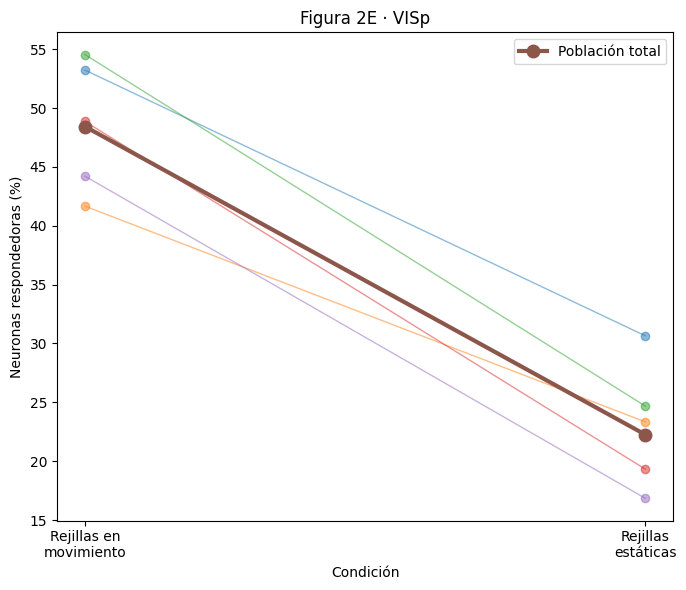

In [41]:
# FIGURA 2E · Parte 1
# Fracción de neuronas respondedoras por condición


umbral = 2.5

# Respondedoras en cada condición
resp_drifting = z_drifting >= umbral
resp_static = z_static >= umbral

# Fracción global
frac_drifting = np.mean(resp_drifting)
frac_static = np.mean(resp_static)

print("REJILLAS EN MOVIMIENTO")
print("Respondedoras:", np.sum(resp_drifting), "/", n_neuronas)
print(f"Fracción: {frac_drifting:.3f}")
print(f"Porcentaje: {100*frac_drifting:.2f}%")

print("\nREJILLAS ESTÁTICAS")
print("Respondedoras:", np.sum(resp_static), "/", n_neuronas)
print(f"Fracción: {frac_static:.3f}")
print(f"Porcentaje: {100*frac_static:.2f}%")
ratones = np.unique(d["u_raton"])

frac_d_por_raton = []
frac_s_por_raton = []

for raton in ratones:

    mask = d["u_raton"] == raton

    fd = np.mean(resp_drifting[mask])
    fs = np.mean(resp_static[mask])

    frac_d_por_raton.append(fd)
    frac_s_por_raton.append(fs)

    print(
        f"Ratón {raton}: "
        f"drifting = {100*fd:.1f}% | "
        f"static = {100*fs:.1f}%"
    )

frac_d_por_raton = np.array(frac_d_por_raton)
frac_s_por_raton = np.array(frac_s_por_raton)
# FIGURA 2E · Puntos conectados

plt.figure(figsize=(7,6))

# Una línea por ratón
for i in range(len(ratones)):

    plt.plot(
        [0, 1],
        [
            100*frac_d_por_raton[i],
            100*frac_s_por_raton[i]
        ],
        marker="o",
        linewidth=1,
        alpha=0.5
    )

# Resultado global
plt.plot(
    [0, 1],
    [
        100*frac_drifting,
        100*frac_static
    ],
    marker="o",
    linewidth=3,
    markersize=9,
    label="Población total"
)

plt.xticks(
    [0, 1],
    [
        "Rejillas en\nmovimiento",
        "Rejillas\nestáticas"
    ]
)

plt.ylabel("Neuronas respondedoras (%)")
plt.xlabel("Condición")

plt.title("Figura 2E · VISp")

plt.legend()

plt.tight_layout()
plt.show()

RESULTADO OBSERVADO
Drifting: 187/382 = 48.95%
Static:   85/382 = 22.25%
Diferencia: 26.70 puntos porcentuales

RESULTADO POR RATÓN
Ratón 715093703: drifting = 53.23% | static = 30.65%
Ratón 750749662: drifting = 41.67% | static = 23.33%
Ratón 760345702: drifting = 55.84% | static = 24.68%
Ratón 762120172: drifting = 50.00% | static = 19.32%
Ratón 798911424: drifting = 44.21% | static = 16.84%

PREPARANDO BOOTSTRAP
Ratón 715093703: 62 neuronas | basal = 150 ensayos | static = 250 ensayos | drifting preferido = [ 9 10] repeticiones
Ratón 750749662: 60 neuronas | basal = 150 ensayos | static = 250 ensayos | drifting preferido = [ 9 10] repeticiones
Ratón 760345702: 77 neuronas | basal = 150 ensayos | static = 250 ensayos | drifting preferido = [ 9 10] repeticiones
Ratón 762120172: 88 neuronas | basal = 150 ensayos | static = 250 ensayos | drifting preferido = [ 9 10] repeticiones
Ratón 798911424: 95 neuronas | basal = 150 ensayos | static = 250 ensayos | drifting preferido = [ 9 10] repe

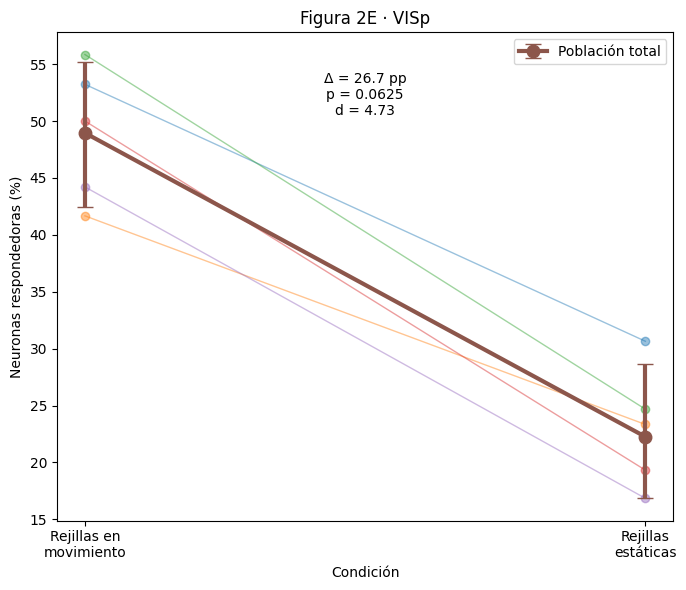

In [42]:
# ============================================================
# FIGURA 2E · ANÁLISIS COMPLETO
# VISp: drifting gratings vs static gratings
#
# Incluye:
# 1. Fracción de neuronas respondedoras
# 2. Fracción por ratón
# 3. Bootstrap jerárquico:
#       ratón -> neurona -> ensayo
# 4. Intervalos de confianza del 95 %
# 5. Prueba de permutación
# 6. d de Cohen
# 7. Figura 2E final
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from itertools import product


# ============================================================
# 0. PARÁMETROS
# ============================================================

umbral = 2.5
N_BOOT = 10000

rng = np.random.default_rng(42)


# ============================================================
# 1. Z-SCORES DEFINITIVOS
# ============================================================

# Para drifting usamos directamente el Z-score calculado
# previamente con la combinación preferida de cada neurona.
#
# Esto corresponde al PASO 4 del notebook.

z_drifting = z_score.copy()


# z_static ya fue calculado en la Figura 2D
# usando todos los ensayos static de cada ratón.

# Comprobación
if len(z_drifting) != n_neuronas:
    raise ValueError("z_drifting no tiene una entrada por neurona.")

if len(z_static) != n_neuronas:
    raise ValueError("z_static no tiene una entrada por neurona.")


# ============================================================
# 2. NEURONAS RESPONDEDORAS
# ============================================================

resp_drifting = z_drifting >= umbral
resp_static = z_static >= umbral


# Fracciones globales
frac_drifting = np.mean(resp_drifting)
frac_static = np.mean(resp_static)

diferencia_observada_global = (
    frac_drifting - frac_static
)


print("==========================================")
print("RESULTADO OBSERVADO")
print("==========================================")

print(
    f"Drifting: "
    f"{np.sum(resp_drifting)}/{n_neuronas} "
    f"= {100*frac_drifting:.2f}%"
)

print(
    f"Static:   "
    f"{np.sum(resp_static)}/{n_neuronas} "
    f"= {100*frac_static:.2f}%"
)

print(
    f"Diferencia: "
    f"{100*diferencia_observada_global:.2f} "
    f"puntos porcentuales"
)


# ============================================================
# 3. FRACCIÓN DE RESPONDEDORAS POR RATÓN
# ============================================================

ratones = np.unique(d["u_raton"])

frac_d_por_raton = []
frac_s_por_raton = []


print("\n==========================================")
print("RESULTADO POR RATÓN")
print("==========================================")


for raton in ratones:

    mask = d["u_raton"] == raton

    fd = np.mean(
        resp_drifting[mask]
    )

    fs = np.mean(
        resp_static[mask]
    )

    frac_d_por_raton.append(fd)
    frac_s_por_raton.append(fs)

    print(
        f"Ratón {raton}: "
        f"drifting = {100*fd:.2f}% | "
        f"static = {100*fs:.2f}%"
    )


frac_d_por_raton = np.array(
    frac_d_por_raton
)

frac_s_por_raton = np.array(
    frac_s_por_raton
)


# ============================================================
# 4. PREPARAR LOS DATOS PARA EL BOOTSTRAP
# ============================================================
#
# Guardamos por separado los datos de cada ratón.
#
# IMPORTANTE:
# drifting_pref NO tiene necesariamente el mismo número
# de ensayos en todas las neuronas.
#
# Algunas tienen 9 y otras 10.
#
# Por eso usamos una matriz rellenada con NaN +
# un vector que guarda cuántos ensayos tiene cada neurona.
# ============================================================

datos_boot = {}


print("\n==========================================")
print("PREPARANDO BOOTSTRAP")
print("==========================================")


for raton in ratones:

    # --------------------------------------------------------
    # Neuronas pertenecientes a este ratón
    # --------------------------------------------------------

    neuronas_r = np.where(
        d["u_raton"] == raton
    )[0]

    n_r = len(neuronas_r)


    # ========================================================
    # BASAL / SPONTANEOUS
    # ========================================================

    ens_spont = np.where(
        (d["e_clase"] == "spontaneous") &
        (d["e_raton"] == raton)
    )[0]

    # Pasar índice global del ensayo a columna
    # de tasa_spontaneous
    cols_spont = map_spontaneous[
        ens_spont
    ]

    basal = tasa_spontaneous[
        np.ix_(
            neuronas_r,
            cols_spont
        )
    ]


    # ========================================================
    # STATIC GRATINGS
    # ========================================================

    ens_static = np.where(
        (d["e_clase"] == "static_gratings") &
        (d["e_raton"] == raton)
    )[0]

    static = tasas_todos_ensayos[
        np.ix_(
            neuronas_r,
            ens_static
        )
    ]


    # ========================================================
    # DRIFTING GRATINGS
    # Condición preferida DE CADA NEURONA
    # ========================================================

    drifting_lista = []


    for i in neuronas_r:

        mask_pref = (

            (d["e_clase"] == "drifting_gratings")

            &

            (d["e_raton"] == raton)

            &

            (
                d["e_orientacion"]
                ==
                orientacion_preferida[i]
            )

            &

            (
                d["e_frec_temporal"]
                ==
                frec_temporal_preferida[i]
            )

            &

            (
                d["e_frec_espacial"]
                ==
                frec_espacial_preferida[i]
            )
        )


        ens_pref = np.where(
            mask_pref
        )[0]


        # Índices globales -> columnas de tasa_drifting
        cols_pref = map_drifting[
            ens_pref
        ]


        tasas_pref = tasa_drifting[
            i,
            cols_pref
        ]


        # Quitar NaN por seguridad
        tasas_pref = tasas_pref[
            np.isfinite(tasas_pref)
        ]


        drifting_lista.append(
            tasas_pref
        )


    # --------------------------------------------------------
    # Número de repeticiones de cada neurona
    # --------------------------------------------------------

    drifting_largos = np.array(
        [
            len(x)
            for x in drifting_lista
        ],
        dtype=int
    )


    if np.any(drifting_largos == 0):

        raise ValueError(
            f"Hay neuronas del ratón {raton} "
            "sin ensayos de su condición preferida."
        )


    max_rep = np.max(
        drifting_largos
    )


    # --------------------------------------------------------
    # Matriz rectangular.
    #
    # Las posiciones que no existen quedan como NaN.
    # --------------------------------------------------------

    drifting_pad = np.full(
        (n_r, max_rep),
        np.nan
    )


    for j, tasas in enumerate(
        drifting_lista
    ):

        drifting_pad[
            j,
            :len(tasas)
        ] = tasas


    print(
        f"Ratón {raton}: "
        f"{n_r} neuronas | "
        f"basal = {basal.shape[1]} ensayos | "
        f"static = {static.shape[1]} ensayos | "
        f"drifting preferido = "
        f"{np.unique(drifting_largos)} repeticiones"
    )


    # --------------------------------------------------------
    # Guardar todo
    # --------------------------------------------------------

    datos_boot[raton] = {

        "neuronas": neuronas_r,

        "basal": basal,

        "static": static,

        "drifting": drifting_pad,

        "drifting_largos": drifting_largos
    }


# ============================================================
# 5. BOOTSTRAP JERÁRQUICO
# ============================================================
#
# En cada réplica:
#
# NIVEL 1:
#   sortear 5 ratones con reemplazo
#
# NIVEL 2:
#   para cada ratón sorteado,
#   sortear sus neuronas con reemplazo
#
# NIVEL 3:
#   para cada neurona sorteada,
#   sortear sus ensayos con reemplazo
#
# El proyecto exige 10 000 réplicas.
# ============================================================

boot_frac_d = np.empty(
    N_BOOT
)

boot_frac_s = np.empty(
    N_BOOT
)


print("\n==========================================")
print("BOOTSTRAP JERÁRQUICO")
print("==========================================")


for b in range(N_BOOT):

    # ========================================================
    # NIVEL 1 · RATONES
    # ========================================================

    ratones_b = rng.choice(
        ratones,
        size=len(ratones),
        replace=True
    )


    respondedoras_d = 0
    respondedoras_s = 0

    total_neuronas = 0


    # --------------------------------------------------------
    # Cada aparición del ratón se procesa independientemente.
    #
    # Si un ratón fue sorteado dos veces,
    # se vuelve a remuestrear desde cero.
    # --------------------------------------------------------

    for raton in ratones_b:

        info = datos_boot[
            raton
        ]

        basal_original = info[
            "basal"
        ]

        static_original = info[
            "static"
        ]

        drifting_original = info[
            "drifting"
        ]

        largos_original = info[
            "drifting_largos"
        ]


        n_r = basal_original.shape[0]


        # ====================================================
        # NIVEL 2 · NEURONAS
        # ====================================================

        idx_neuronas = rng.integers(
            0,
            n_r,
            size=n_r
        )


        basal = basal_original[
            idx_neuronas
        ]

        static = static_original[
            idx_neuronas
        ]

        drifting = drifting_original[
            idx_neuronas
        ]

        largos = largos_original[
            idx_neuronas
        ]


        # ====================================================
        # NIVEL 3A · ENSAYOS BASALES
        # ====================================================

        n_basal = basal.shape[1]


        idx_basal = rng.integers(
            0,
            n_basal,
            size=basal.shape
        )


        basal_b = np.take_along_axis(
            basal,
            idx_basal,
            axis=1
        )


        media_basal_b = np.mean(
            basal_b,
            axis=1
        )


        std_basal_b = np.std(
            basal_b,
            axis=1,
            ddof=0
        )


        # Evitar divisiones por exactamente cero
        std_basal_b = np.maximum(
            std_basal_b,
            1e-12
        )


        # ====================================================
        # NIVEL 3B · ENSAYOS STATIC
        # ====================================================

        n_static = static.shape[1]


        idx_static = rng.integers(
            0,
            n_static,
            size=static.shape
        )


        static_b = np.take_along_axis(
            static,
            idx_static,
            axis=1
        )


        media_static_b = np.mean(
            static_b,
            axis=1
        )


        # ====================================================
        # NIVEL 3C · ENSAYOS DRIFTING
        # ====================================================
        #
        # Aquí está la corrección importante:
        #
        # cada neurona mantiene SU número original
        # de ensayos de la condición preferida.
        #
        # Si tenía 9 -> remuestreamos 9.
        # Si tenía 10 -> remuestreamos 10.
        # ====================================================

        max_rep = drifting.shape[1]


        # Número aleatorio entre 0 y 1
        # para cada posible ensayo
        u = rng.random(
            size=drifting.shape
        )


        # Convertir ese número al rango válido
        # de cada neurona individualmente
        idx_drifting = (
            u * largos[:, None]
        ).astype(int)


        drifting_b = np.take_along_axis(
            drifting,
            idx_drifting,
            axis=1
        )


        # Máscara:
        # si la neurona tiene 9 ensayos,
        # usamos solo las primeras 9 columnas.
        columnas = np.arange(
            max_rep
        )[None, :]


        mask_validos = (
            columnas
            <
            largos[:, None]
        )


        # Suma de ensayos remuestreados
        suma_drifting = np.sum(
            np.where(
                mask_validos,
                drifting_b,
                0
            ),
            axis=1
        )


        media_drifting_b = (
            suma_drifting
            /
            largos
        )


        # ====================================================
        # RECALCULAR Z-SCORE
        # ====================================================

        z_d_b = (
            media_drifting_b
            -
            media_basal_b
        ) / std_basal_b


        z_s_b = (
            media_static_b
            -
            media_basal_b
        ) / std_basal_b


        # ====================================================
        # CLASIFICAR RESPONDEDORAS
        # ====================================================

        respondedoras_d += np.sum(
            z_d_b >= umbral
        )

        respondedoras_s += np.sum(
            z_s_b >= umbral
        )


        total_neuronas += n_r


    # ========================================================
    # ESTADÍSTICO DE ESTA RÉPLICA
    # ========================================================

    boot_frac_d[b] = (
        respondedoras_d
        /
        total_neuronas
    )


    boot_frac_s[b] = (
        respondedoras_s
        /
        total_neuronas
    )


    # Mostrar progreso
    if (b + 1) % 1000 == 0:

        print(
            f"Bootstrap "
            f"{b+1}/{N_BOOT}"
        )


# ============================================================
# 6. INTERVALOS DE CONFIANZA DEL 95 %
# ============================================================

boot_diferencia = (
    boot_frac_d
    -
    boot_frac_s
)


IC_drifting = np.percentile(
    boot_frac_d,
    [2.5, 97.5]
)


IC_static = np.percentile(
    boot_frac_s,
    [2.5, 97.5]
)


IC_diferencia = np.percentile(
    boot_diferencia,
    [2.5, 97.5]
)


print("\n==========================================")
print("RESULTADO DEL BOOTSTRAP")
print("==========================================")


print(
    f"Drifting = "
    f"{100*frac_drifting:.2f}% "
    f"[IC95%: "
    f"{100*IC_drifting[0]:.2f}%, "
    f"{100*IC_drifting[1]:.2f}%]"
)


print(
    f"Static = "
    f"{100*frac_static:.2f}% "
    f"[IC95%: "
    f"{100*IC_static[0]:.2f}%, "
    f"{100*IC_static[1]:.2f}%]"
)


print(
    f"Diferencia = "
    f"{100*diferencia_observada_global:.2f} pp "
    f"[IC95%: "
    f"{100*IC_diferencia[0]:.2f}, "
    f"{100*IC_diferencia[1]:.2f} pp]"
)


# ============================================================
# 7. PRUEBA DE PERMUTACIÓN
# ============================================================
#
# Unidad estadística: RATÓN
#
# Tenemos una fracción drifting y una fracción static
# para cada uno de los cinco ratones.
#
# Como las mediciones son pareadas, bajo H0 podemos
# intercambiar el signo de la diferencia de cada ratón.
#
# Con cinco ratones:
#
#        2^5 = 32
#
# combinaciones posibles.
#
# Las hacemos TODAS.
# ============================================================

diferencias_raton = (
    frac_d_por_raton
    -
    frac_s_por_raton
)


delta_raton_observado = np.mean(
    diferencias_raton
)


# Todas las combinaciones posibles
# de signos -1 y +1

signos = np.array(
    list(
        product(
            [-1, 1],
            repeat=len(ratones)
        )
    )
)


# Diferencia media bajo cada permutación
distribucion_perm = np.mean(
    signos
    *
    diferencias_raton,
    axis=1
)


# Prueba bilateral
p_valor = np.mean(
    np.abs(
        distribucion_perm
    )
    >=
    np.abs(
        delta_raton_observado
    )
)


# ============================================================
# 8. d DE COHEN
# ============================================================
#
# Datos pareados:
#
# d = media de las diferencias /
#     SD de las diferencias
#
# Unidad estadística = ratón
# ============================================================

sd_diferencias = np.std(
    diferencias_raton,
    ddof=1
)


if sd_diferencias > 0:

    d_cohen = (
        np.mean(
            diferencias_raton
        )
        /
        sd_diferencias
    )

else:

    d_cohen = np.nan


print("\n==========================================")
print("PERMUTACIÓN Y TAMAÑO DEL EFECTO")
print("==========================================")


print(
    f"Diferencia media por ratón: "
    f"{100*delta_raton_observado:.2f} "
    f"puntos porcentuales"
)


print(
    f"p de permutación = "
    f"{p_valor:.4f}"
)


print(
    f"d de Cohen = "
    f"{d_cohen:.3f}"
)


# ============================================================
# 9. RESUMEN FINAL
# ============================================================

print("\n==========================================")
print("RESUMEN PARA FIGURA 2E")
print("==========================================")


print(
    f"Drifting: "
    f"{100*frac_drifting:.2f}% "
    f"(IC95% "
    f"{100*IC_drifting[0]:.2f}–"
    f"{100*IC_drifting[1]:.2f}%)"
)


print(
    f"Static: "
    f"{100*frac_static:.2f}% "
    f"(IC95% "
    f"{100*IC_static[0]:.2f}–"
    f"{100*IC_static[1]:.2f}%)"
)


print(
    f"Diferencia: "
    f"{100*diferencia_observada_global:.2f} pp "
    f"(IC95% "
    f"{100*IC_diferencia[0]:.2f}–"
    f"{100*IC_diferencia[1]:.2f} pp)"
)


print(
    f"p = {p_valor:.4f}"
)


print(
    f"d = {d_cohen:.3f}"
)


# ============================================================
# 10. FIGURA 2E FINAL
# ============================================================

plt.figure(
    figsize=(7, 6)
)


# ------------------------------------------------------------
# Líneas individuales de los cinco ratones
# ------------------------------------------------------------

for i in range(
    len(ratones)
):

    plt.plot(
        [0, 1],
        [
            100 * frac_d_por_raton[i],
            100 * frac_s_por_raton[i]
        ],
        marker="o",
        linewidth=1,
        alpha=0.45
    )


# ------------------------------------------------------------
# Resultados globales
# ------------------------------------------------------------

x = np.array(
    [0, 1]
)


medias = 100 * np.array(
    [
        frac_drifting,
        frac_static
    ]
)


# ------------------------------------------------------------
# Barras de error asimétricas
# usando IC95% bootstrap
# ------------------------------------------------------------

error_inferior = 100 * np.array(
    [
        frac_drifting - IC_drifting[0],
        frac_static - IC_static[0]
    ]
)


error_superior = 100 * np.array(
    [
        IC_drifting[1] - frac_drifting,
        IC_static[1] - frac_static
    ]
)


errores = np.vstack(
    [
        error_inferior,
        error_superior
    ]
)


plt.errorbar(
    x,
    medias,
    yerr=errores,
    marker="o",
    linewidth=3,
    markersize=9,
    capsize=6,
    label="Población total"
)


# ------------------------------------------------------------
# Etiquetas
# ------------------------------------------------------------

plt.xticks(
    [0, 1],
    [
        "Rejillas en\nmovimiento",
        "Rejillas\nestáticas"
    ]
)


plt.ylabel(
    "Neuronas respondedoras (%)"
)


plt.xlabel(
    "Condición"
)


plt.title(
    "Figura 2E · VISp"
)


# ------------------------------------------------------------
# Texto estadístico
# ------------------------------------------------------------

texto = (
    f"Δ = "
    f"{100*diferencia_observada_global:.1f} pp\n"
    f"p = {p_valor:.4f}\n"
    f"d = {d_cohen:.2f}"
)


# Posición automática dentro de la figura
ymax = plt.ylim()[1]


plt.text(
    0.5,
    ymax * 0.94,
    texto,
    ha="center",
    va="top"
)


plt.legend()

plt.tight_layout()

plt.show()